In [ ]:
import os

from dotenv import load_dotenv
from typing import Literal
from typing_extensions import TypedDict

from pydantic import BaseModel, Field

from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate

from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, START, END  

In [105]:
load_dotenv()

True

In [95]:
llm1 = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=os.environ['GROQ_API_KEY1']
    # other params...
)

llm2 = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=os.environ['GROQ_API_KEY2']
    # other params...
)

llm3 = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=os.environ['GROQ_API_KEY3']
    # other params...
)

In [96]:
class SentimentSchema(BaseModel):
    sentiment : Literal['positive', 'negative'] = Field(description = "return sentiment of the review either negative, positive")

In [97]:
parser = PydanticOutputParser(pydantic_object=SentimentSchema)

In [98]:
template1 = PromptTemplate(
    template="Extract the sentiment of following review \n {review} \n {format_instruction}",
    input_variables=['review'],
    partial_variables={
        "format_instruction": parser.get_format_instructions()}
)

In [101]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [103]:
parser2 = PydanticOutputParser(pydantic_object=DiagnosisSchema)

In [104]:
template2 = PromptTemplate(
    template="""Diagnose this negative review:\n{review}\n {format_instruction}""",
    input_variables=['review'],
    partial_variables={
        "format_instruction": parser2.get_format_instructions()}
)

In [102]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [91]:
def find_sentiment(state : ReviewState):
    out = template1 | llm2 | parser
    result = out.invoke({'review' : state['review']})
    return {'sentiment' : result.sentiment}

def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = llm1.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    output = template2 | llm3 | parser2
    response = output.invoke({'review' : state['review']})

    return {'diagnosis': response.model_dump()}


def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = llm3.invoke(prompt).content

    return {'response': response}


In [120]:
def check_sentiment(state):
    if state["sentiment"] == "positive":
        return "YES"
    else:
        return "NO"

In [121]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('node_positive_response', positive_response)
graph.add_node('node_run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

# graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_conditional_edges(
    "find_sentiment",
    check_sentiment,
    {
        "YES": "node_positive_response",
        "NO": "node_run_diagnosis",
    },
)
graph.add_edge('node_positive_response', END)

graph.add_edge('node_run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

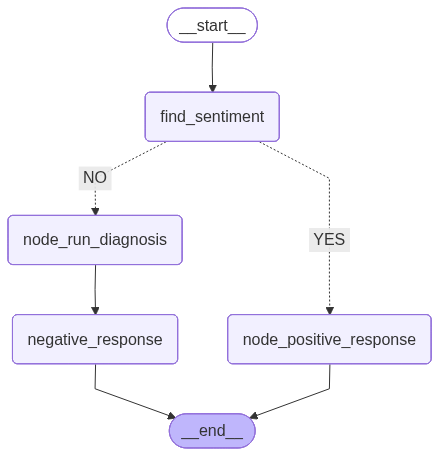

In [125]:
workflow

In [124]:
result = workflow.invoke({
    "review": "The app keeps crashing every time I open it."
})

print(result)

{'review': 'The app keeps crashing every time I open it.', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'}, 'response': "**Subject:** Urgent: Resolving Your Issue ASAP  \n\nHi [User's Name],  \n\nThank you for reaching out and sharing the bug you’re experiencing. I completely understand how frustrating this must be, especially with the urgency you’ve highlighted, and I want to assure you that I’m here to help resolve this as quickly as possible.  \n\nTo get started, could you please provide the following details so I can investigate further?  \n1. **Steps to reproduce the issue** (e.g., what actions led to the bug?).  \n2. **Any error messages or screenshots** (if applicable).  \n3. **Device/browser/app version** you’re using.  \n\nI’ll prioritize your case and work closely with our team to address this. If you’re comfortable, I can also check your account directly for any anomalies. Please let me know if you’d like to share login de